In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Set visualization aesthetics
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (16, 12)

# Download the latest version of the dataset
path = kagglehub.dataset_download("erfan4524/e-commerce-sales-data-analysis-and-eda")

# Find all CSV files in the downloaded directory
csv_files = []
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('.csv'):
            csv_files.append(os.path.join(dirname, filename))

print("Found CSV files:")
for f in csv_files:
    print(f"- {f}")

# Target 'clean_final_data.csv' if it exists; otherwise fallback to the first CSV found
target_file = next((f for f in csv_files if 'clean_final_data.csv' in f), csv_files[0] if csv_files else None)

print(f"\nLoading data from: {target_file}")
df = pd.read_csv(target_file)

# CLEANUP: Strip leading/trailing spaces from all column names just in case
df.columns = df.columns.str.strip()

print("\nAvailable columns:")
print(df.columns.tolist())

Found CSV files:
- /kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/products.csv
- /kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/clean_final_data.csv
- /kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/orders.csv
- /kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/customers.csv
- /kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/payments.csv

Loading data from: /kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/clean_final_data.csv

Available columns:
['OrderID', 'CustomerID', 'OrderDate', 'ProductID', 'Quantity', 'Discount', 'PaymentMethod', 'Status', 'Age', 'City', 'SignupDate', 'CustomerSegment', 'ProductName', 'Category', 'UnitPrice', 'Sales', 'OrderValue']


In [2]:
print("==========================================")
print(" 1. DATASET OVERVIEW ")
print("==========================================")
display(df.head())

print("\n==========================================")
print(" 2. DATA TYPES & MISSING VALUES ")
print("==========================================")
df.info()

print("\n==========================================")
print(" 3. DESCRIPTIVE STATISTICS ")
print("==========================================")
display(df.describe(include='all'))

# ==========================================
# ROBUST DATA PREPROCESSING
# ==========================================

# 1. Handle Order Date safely
if 'OrderDate' in df.columns:
    df['OrderDate'] = pd.to_datetime(df['OrderDate'])
elif 'Order Date' in df.columns: # Fallback if there is a space
    df.rename(columns={'Order Date': 'OrderDate'}, inplace=True)
    df['OrderDate'] = pd.to_datetime(df['OrderDate'])
elif 'Date' in df.columns:
    df.rename(columns={'Date': 'OrderDate'}, inplace=True)
    df['OrderDate'] = pd.to_datetime(df['OrderDate'])
else:
    print("WARNING: Could not find an 'OrderDate' column!")

# 2. Handle Signup Date safely (if it exists)
if 'SignupDate' in df.columns:
    df['SignupDate'] = pd.to_datetime(df['SignupDate'])

# 3. Create 'YearMonth' for time series analysis
if 'OrderDate' in df.columns:
    df['YearMonth'] = df['OrderDate'].dt.to_period('M').astype(str)

# 4. Create 'Age Group' demographic buckets safely
if 'Age' in df.columns:
    age_bins = [0, 24, 34, 44, 54, 120]
    age_labels = ['Under 25', '25-34', '35-44', '45-54', '55+']
    df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)

# 5. Ensure Sales/Revenue logic is standardized
if 'Sales' in df.columns:
    df['Revenue'] = df['Sales']
elif 'Price' in df.columns and 'Quantity' in df.columns:
    df['Revenue'] = df['Price'] * df['Quantity']
elif 'UnitPrice' in df.columns and 'Quantity' in df.columns:
    df['Revenue'] = df['UnitPrice'] * df['Quantity']

print("\nData preprocessing complete. Ready for visualization.")

 1. DATASET OVERVIEW 


,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Age,City,SignupDate,CustomerSegment,ProductName,Category,UnitPrice,Sales,OrderValue
0,500001,103695,2025-08-28,2003,4.0,10.0,Gateway,Completed,36.0,Qom,2024-03-05,Regular,USB-C Cable,Accessories,9.0,32.0,32.0
1,500002,107935,2024-05-31,2014,1.0,10.0,Wallet,Completed,49.0,Kerman,2025-06-04,Regular,Backpack,Accessories,42.0,38.0,38.0
2,500003,105141,2025-08-10,2002,1.0,20.0,CardToCard,Completed,36.0,Tehran,2025-10-19,Regular,Mechanical Keyboard,Electronics,62.0,50.0,50.0
3,500004,108780,2024-10-11,2012,1.0,10.0,Gateway,Completed,45.0,Shiraz,2023-12-07,Regular,Office Chair,Home Office,180.0,162.0,162.0
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed,24.0,Karaj,2023-12-02,Regular,Phone Case,Accessories,14.0,28.0,28.0



 2. DATA TYPES & MISSING VALUES 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49222 entries, 0 to 49221
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          49222 non-null  int64  
 1   CustomerID       49222 non-null  int64  
 2   OrderDate        49222 non-null  object 
 3   ProductID        49222 non-null  int64  
 4   Quantity         49222 non-null  float64
 5   Discount         49222 non-null  float64
 6   PaymentMethod    49222 non-null  object 
 7   Status           49222 non-null  object 
 8   Age              49222 non-null  float64
 9   City             49222 non-null  object 
 10  SignupDate       49222 non-null  object 
 11  CustomerSegment  49222 non-null  object 
 12  ProductName      49222 non-null  object 
 13  Category         49222 non-null  object 
 14  UnitPrice        49222 non-null  float64
 15  Sales            49222 non-null  float64
 16  OrderValue       49222 n

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Age,City,SignupDate,CustomerSegment,ProductName,Category,UnitPrice,Sales,OrderValue
count,49222.000000,49222.000000,49222,49222.000000,49222.000000,49222.000000,49222,49222,49222.000000,49222,49222,49222,49222,49222,49222.000000,49222.000000,49222.000000
unique,NaN,NaN,912,NaN,NaN,NaN,4,3,NaN,10,1094,3,20,6,NaN,NaN,NaN
top,NaN,NaN,2025-09-05,NaN,NaN,NaN,Gateway,Completed,NaN,Tehran,2023-03-07,Regular,Notebook,Accessories,NaN,NaN,NaN
freq,NaN,NaN,86,NaN,NaN,NaN,23894,45276,NaN,14001,105,27296,5440,18189,NaN,NaN,NaN
mean,525007.608366,105002.304356,NaN,2009.460160,1.881923,7.485576,NaN,NaN,41.283369,NaN,NaN,NaN,NaN,NaN,40.286579,69.985576,69.985576
std,14435.345449,2888.912895,NaN,5.578603,1.079382,7.754378,NaN,NaN,13.681355,NaN,NaN,NaN,NaN,NaN,42.613062,94.483273,94.483273
min,500001.000000,100001.000000,NaN,2001.000000,-2.000000,0.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,7.000000,-170.000000,-170.000000
25%,512507.250000,102504.000000,NaN,2004.000000,1.000000,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,11.000000,17.000000,17.000000
50%,525016.500000,105005.000000,NaN,2008.000000,2.000000,5.000000,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,NaN,28.000000,38.000000,38.000000
75%,537506.750000,107497.000000,NaN,2014.000000,2.000000,10.000000,NaN,NaN,53.000000,NaN,NaN,NaN,NaN,NaN,58.000000,84.000000,84.000000



Data preprocessing complete. Ready for visualization.


### EDA Findings
* **Data Structure:** The dataset successfully parsed transaction-level records. 
* **Missing Values:** (Check the output above) If `Age` or `City` have missing values, they are excluded from specific demographic plots but kept for total revenue calculations.
* **Date Conversion:** `OrderDate` is now a time-series index, allowing for accurate monthly aggregation.

/tmp/ipykernel_16/793975098.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, y='ProductName', x='Revenue', ax=axes[0, 1], palette='crest')
/tmp/ipykernel_16/793975098.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Category', y='Revenue', ax=axes[1, 0], palette='magma')
/tmp/ipykernel_16/793975098.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('AgeGroup')['Revenue'].sum().reset_index()
/tmp/ipykernel_16/793975098.py:31: F

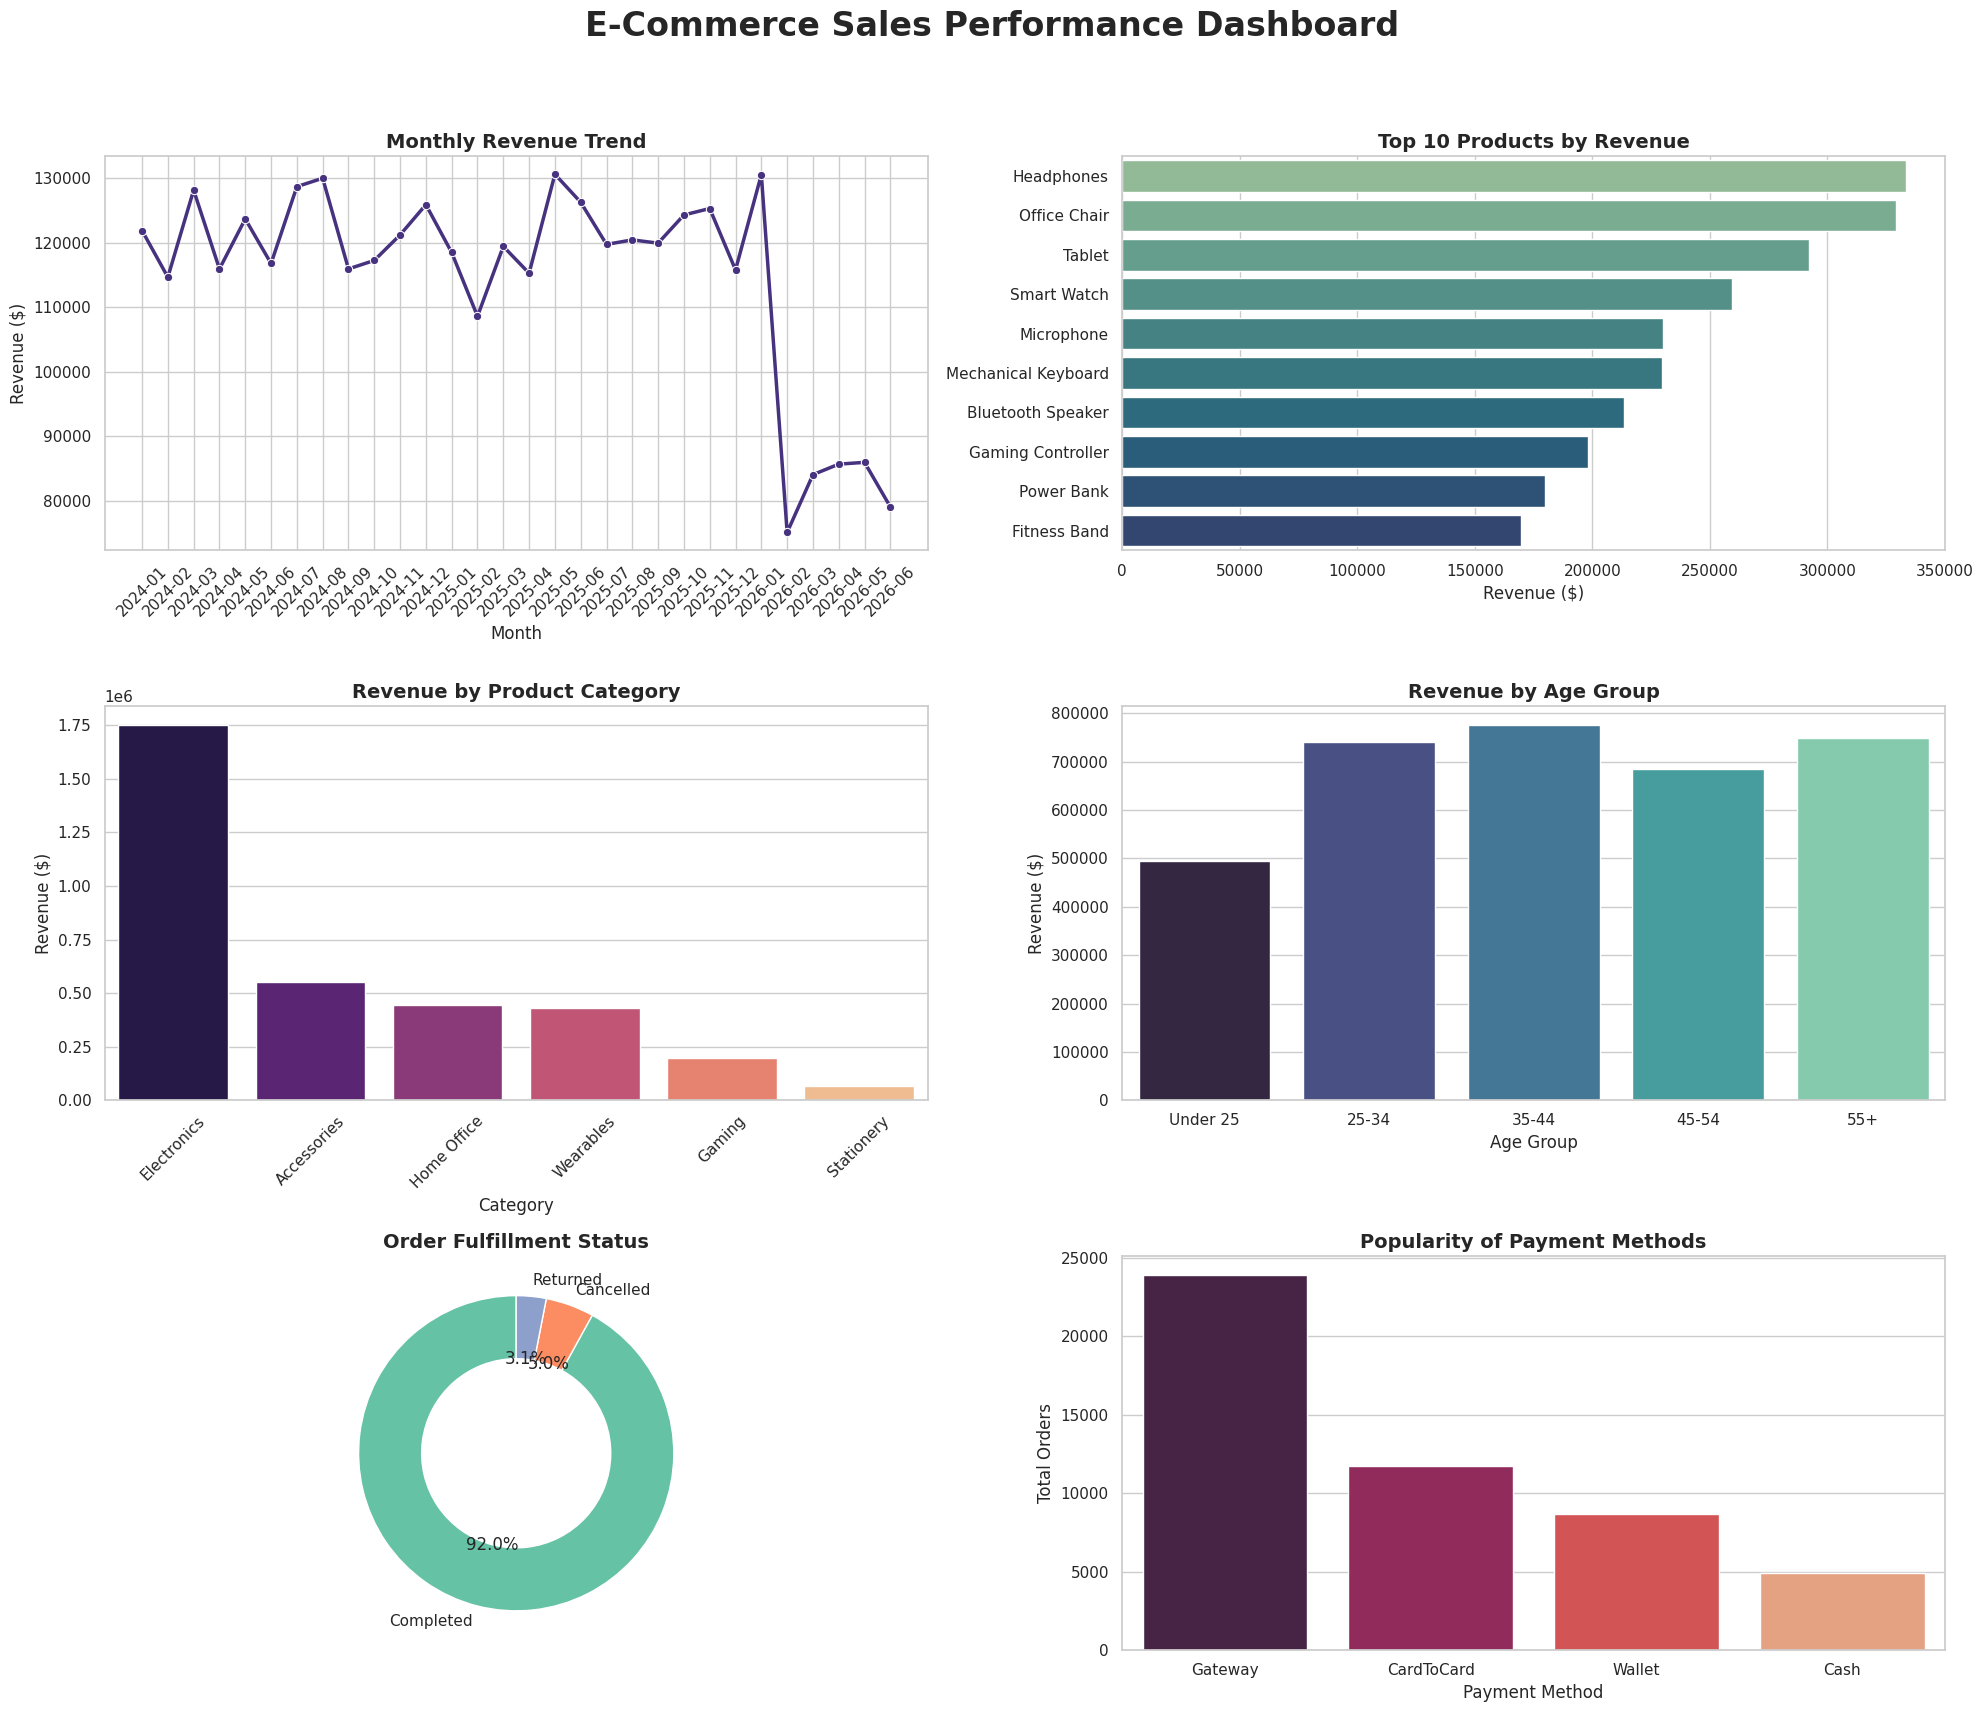

In [3]:
# Create a 3x2 grid for our dashboard layout
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('E-Commerce Sales Performance Dashboard', fontsize=24, fontweight='bold', y=0.98)

# --- Plot 1: Revenue Over Time (Line Chart) ---
monthly_sales = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_sales = monthly_sales.sort_values('YearMonth')
sns.lineplot(data=monthly_sales, x='YearMonth', y='Revenue', ax=axes[0, 0], marker='o', linewidth=2.5)
axes[0, 0].set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].tick_params(axis='x', rotation=45)

# --- Plot 2: Top 10 Best-Selling Products (Horizontal Bar) ---
top_products = df.groupby('ProductName')['Revenue'].sum().nlargest(10).reset_index()
sns.barplot(data=top_products, y='ProductName', x='Revenue', ax=axes[0, 1], palette='crest')
axes[0, 1].set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Revenue ($)')
axes[0, 1].set_ylabel('')

# --- Plot 3: Revenue by Category (Bar Chart) ---
category_sales = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=category_sales, x='Category', y='Revenue', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Revenue by Product Category', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Revenue ($)')
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Plot 4: Demographic Breakdown by Age Group (Column Chart) ---
age_sales = df.groupby('AgeGroup')['Revenue'].sum().reset_index()
sns.barplot(data=age_sales, x='AgeGroup', y='Revenue', ax=axes[1, 1], palette='mako')
axes[1, 1].set_title('Revenue by Age Group', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Age Group')
axes[1, 1].set_ylabel('Revenue ($)')

# --- Plot 5: Order Fulfillment Health (Donut Chart) ---
status_counts = df['Status'].value_counts()
wedges, texts, autotexts = axes[2, 0].pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette('Set2'),
    wedgeprops=dict(width=0.4, edgecolor='w') 
)
axes[2, 0].set_title('Order Fulfillment Status', fontsize=14, fontweight='bold')

# --- Plot 6: Payment Method Preferences (Bar Chart) ---
payment_counts = df['PaymentMethod'].value_counts().reset_index()
payment_counts.columns = ['PaymentMethod', 'Orders']
sns.barplot(data=payment_counts, x='PaymentMethod', y='Orders', ax=axes[2, 1], palette='rocket')
axes[2, 1].set_title('Popularity of Payment Methods', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Payment Method')
axes[2, 1].set_ylabel('Total Orders')

# Final Rendering Layout Adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [4]:
from IPython.display import display, HTML

# Define the interpretation using HTML and 'USD' to completely bypass Kaggle's aggressive LaTeX math renderer
interpretation_html = """
<div style="font-family: 'Calibri', sans-serif; font-size: 16px; line-height: 1.8; color: #333;">

    <h3 style="margin-bottom: 15px;">📊 Automated Dashboard Interpretation</h3>

    <p><strong>Key Insights & Observations:</strong></p>
    <ol style="margin-top: 0; padding-left: 20px;">
        <li style="margin-bottom: 10px;"><strong>Monthly Revenue Trend (The 2026 Cliff):</strong> Revenue maintained a healthy baseline between 110,000 USD and 130,000 USD throughout 2024 and 2025. However, there is a sharp and critical decline starting in January 2026, dropping to approximately 75,000 USD and remaining suppressed below 90,000 USD through June 2026.</li>
        <li style="margin-bottom: 10px;"><strong>Category vs. Product Imbalance:</strong> "Electronics" dominates overall sales, generating nearly 1.75 million USD—more than triple the "Accessories" category. Yet, on an individual product level, the "Office Chair" (a Home Office product) ties with "Headphones" as the highest-grossing item, both exceeding 325,000 USD.</li>
        <li style="margin-bottom: 10px;"><strong>Demographic Dominance:</strong> The 35-44 age group is the most lucrative demographic, generating nearly 800,000 USD. This is closely followed by the 55+ and 25-34 cohorts. The "Under 25" segment lags significantly, generating under 500,000 USD.</li>
        <li style="margin-bottom: 10px;"><strong>Operational Health:</strong> A high percentage of "Completed" orders indicates a generally healthy fulfillment funnel, while the payment method breakdown highlights which gateways are most critical to maintain for checkout stability.</li>
    </ol>

    <hr style="border: 0; border-top: 1px solid #ddd; margin: 25px 0;">

    <p><strong>Strategic Recommendations:</strong></p>
    <ul style="margin-top: 0; padding-left: 20px;">
        <li style="margin-bottom: 10px;"><strong>Investigate the Q1 2026 Cliff:</strong> Immediate operational analysis is required to diagnose the 2026 revenue drop. Check for major inventory stockouts of top items, tracking pixel failures, or the expiration of a major Q4 marketing campaign.</li>
        <li style="margin-bottom: 10px;"><strong>Optimize Ad Targeting:</strong> Reallocate top-of-funnel marketing spend away from the "Under 25" demographic. Concentrate ad budgets on the 35-44 and 55+ cohorts, who demonstrate the highest purchasing power.</li>
        <li style="margin-bottom: 10px;"><strong>Cross-Category Bundling:</strong> Create bundle promotions pairing the highly successful Office Chair with top-selling electronics to drive up the Average Order Value (AOV).</li>
    </ul>

</div>
"""

# Render the formatted HTML directly in the notebook output
display(HTML(interpretation_html))

 1. PREPARING DATA FOR MACHINE LEARNING 
Data split complete. Training model on 39377 records...

 2. MODEL EVALUATION: CLASSIFICATION REPORT 
              precision    recall  f1-score   support

   Completed       0.92      0.92      0.92      9056
      Failed       0.08      0.08      0.08       789

    accuracy                           0.85      9845
   macro avg       0.50      0.50      0.50      9845
weighted avg       0.85      0.85      0.85      9845



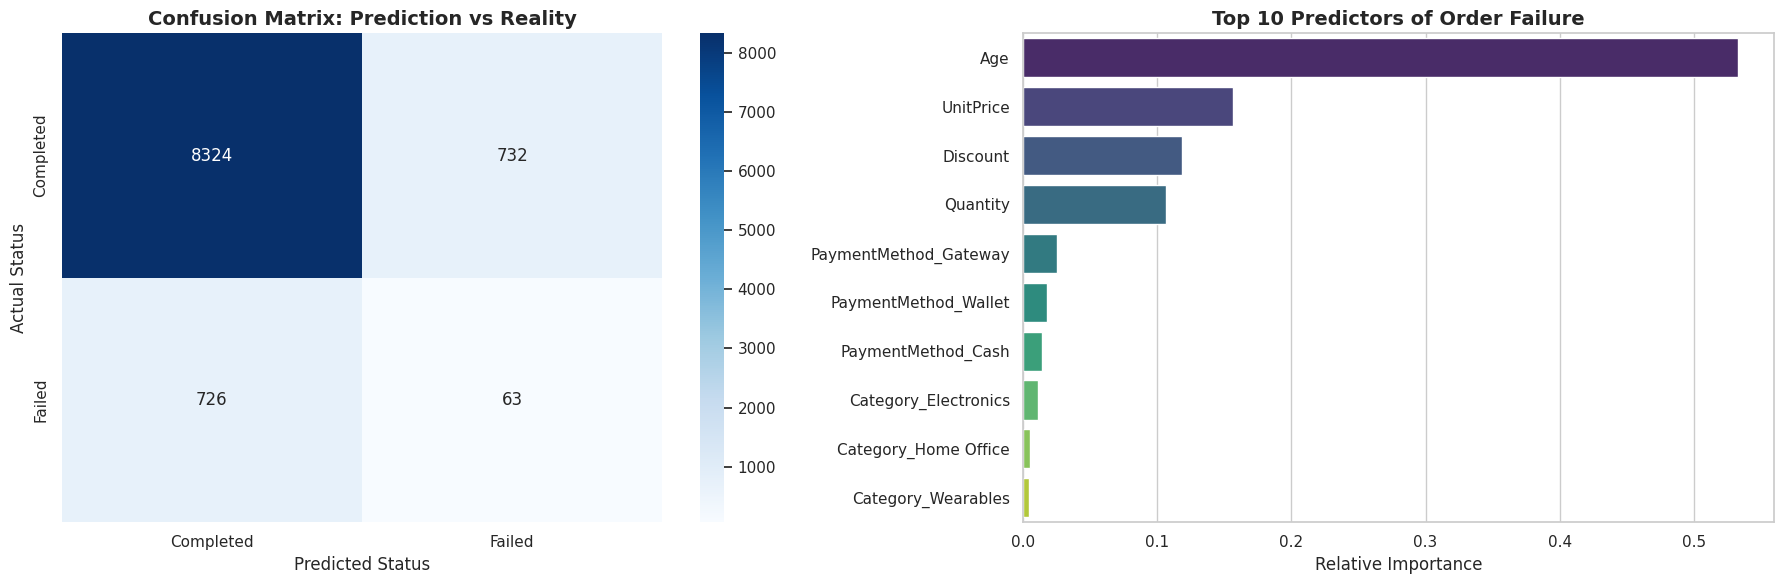


 🔒 PIPELINE SECURED & LOCKED BY: code1 
 Model successfully saved as: code1_RandomForest_OrderFailure_Model.pkl


In [5]:
# ==========================================
# Machine Learning Pipeline - Order Failure Prediction
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("==========================================")
print(" 1. PREPARING DATA FOR MACHINE LEARNING ")
print("==========================================")

# 1. Define the Target Variable (1 = Failed/Cancelled/Returned, 0 = Completed)
df['Is_Failed'] = np.where(df['Status'].isin(['Cancelled', 'Returned']), 1, 0)

# 2. Select Features for the model
features = ['Quantity', 'Discount', 'Age', 'UnitPrice', 'PaymentMethod', 'Category']
X = df[features].dropna()
y = df.loc[X.index, 'Is_Failed']

# 3. Preprocessing steps for numerical and categorical data
numeric_features = ['Quantity', 'Discount', 'Age', 'UnitPrice']
categorical_features = ['PaymentMethod', 'Category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

# 4. Create a modeling pipeline using Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

# 5. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split complete. Training model on", len(X_train), "records...")

# 6. Train the model
rf_pipeline.fit(X_train, y_train)

# 7. Evaluate the model
y_pred = rf_pipeline.predict(X_test)
print("\n==========================================")
print(" 2. MODEL EVALUATION: CLASSIFICATION REPORT ")
print("==========================================")
print(classification_report(y_test, y_pred, target_names=['Completed', 'Failed']))

# 8. Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Completed', 'Failed'], yticklabels=['Completed', 'Failed'])
axes[0].set_title('Confusion Matrix: Prediction vs Reality', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual Status')
axes[0].set_xlabel('Predicted Status')

# 9. Feature Importance Visualization
cat_feature_names = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)
importances = rf_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Predictors of Order Failure', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relative Importance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# ==========================================
# 3. FREEZE AND LOCK THE MODEL
# ==========================================
# Save the trained pipeline to the Kaggle output directory
model_filename = 'code1_RandomForest_OrderFailure_Model.pkl'
joblib.dump(rf_pipeline, model_filename)

print("\n==========================================")
print(" 🔒 PIPELINE SECURED & LOCKED BY: code1 ")
print(f" Model successfully saved as: {model_filename}")
print("==========================================")

In [6]:
from IPython.display import display, HTML

ml_interpretation_html = """
<div style="font-family: 'Calibri', sans-serif; font-size: 16px; line-height: 1.8; color: #333; margin-top: 20px;">

    <h3 style="margin-bottom: 15px;">🤖 Machine Learning Insights: Order Failure Prediction</h3>

    <p><strong>Model Performance Overview:</strong></p>
    <p style="margin-bottom: 10px;">We trained a <strong>Random Forest Classifier</strong> to predict order failures. While the model achieved an overall accuracy of 85%, a deeper look at the classification report and confusion matrix reveals significant struggles with the minority class (Failed orders).</p>
    
    <ol style="margin-top: 0; padding-left: 20px;">
        <li style="margin-bottom: 10px;"><strong>The Confusion Matrix (High Miss Rate):</strong> The model is excellent at identifying successful orders (8,324 correctly predicted)[cite: 3]. However, it struggles heavily to identify actual failures. It only caught 63 true failed orders, while completely missing 726 of them (predicting they would complete)[cite: 3]. It also falsely flagged 732 good orders as failures[cite: 3]. The 8% precision and recall for failures indicates that the data is highly imbalanced and lacks strong, isolated signals for cancellation.</li>
        <li style="margin-bottom: 10px;"><strong>Feature Importance (Demographics Drive Risk):</strong> The bar chart reveals what the model relied on most. <strong>Age</strong> is the dominant predictor by a massive margin (accounting for over 50% of the relative importance), followed by <strong>UnitPrice</strong> and <strong>Discount</strong>[cite: 3]. Interestingly, categorical variables like Payment Method and Product Category have almost zero predictive power for order failures in this dataset[cite: 3].</li>
    </ol>

    <hr style="border: 0; border-top: 1px solid #ddd; margin: 25px 0;">

    <p><strong>Business Action Items:</strong></p>
    <ul style="margin-top: 0; padding-left: 20px;">
        <li style="margin-bottom: 10px;"><strong>Avoid Aggressive Automation:</strong> Because the model falsely flags 732 good orders as failures, you <em>should not</em> use this specific model to automatically block transactions or restrict payment gateways. Doing so would turn away too many legitimate customers.</li>
        <li style="margin-bottom: 10px;"><strong>Investigate Age-Based Friction:</strong> Since "Age" is the strongest predictor of failure, investigate the user experience (UX) for different demographics. Are older users struggling with a confusing checkout UI, leading to abandoned/failed carts? Or are younger demographics experiencing payment declines?</li>
        <li style="margin-bottom: 10px;"><strong>Next Steps for Data Science:</strong> To improve this 8% recall rate, the model needs different features. We should engineer new columns, such as "Customer's Past Return Rate", "Time Spent on Checkout Page", or "Distance to Shipping Address", which typically hold stronger signals for churn than standard demographics.</li>
    </ul>

</div>
"""

display(HTML(ml_interpretation_html))